In [4]:
import numpy as np
from matplotlib import pyplot as plt

from road_gen.integrator.integrator import integrate_road
from road_gen.plotting.plot_road import plot_road

# Random roads using white noise

Let's populate the discrete curvature field $\{\kappa_0, \kappa_1 ... \kappa_{N-1}\}$ with random samples

$$
\kappa_i \sim \mathcal{N}(0, 1), \quad \text{for } i = 0, 1, \ldots, N-1,
$$

where \(N\) is the number of waypoints along the road. Let's see an example:

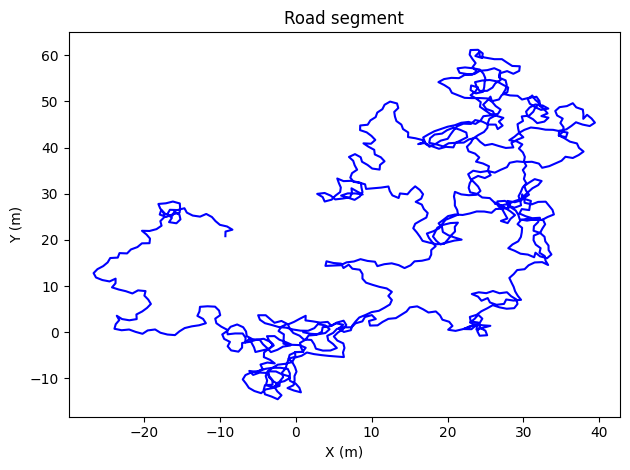

In [144]:
white_noise_curvature = np.random.randn(1000)
x, y = integrate_road(white_noise_curvature)
plot_road(x, y)

#### Clipping

Of course no real road looks like this! But one thing we can do is to define a new hyperparameter $\kappa_{max} \equiv 1/R_{min}$ where $R_{min}$ is the minimum radius of the curvature. Just like a real turn in the road it can't be too sharp or cars cannot take the turn. Let's say we want a minimum of $25$ meters of turning radius. We clip all turns which are too sharp:

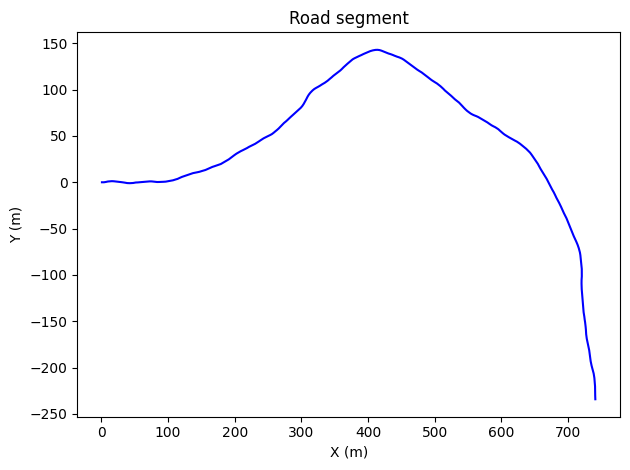

In [145]:
kappa_max = 1 / 25
clipped_wn_curvature = np.clip(white_noise_curvature, -kappa_max, kappa_max)
x, y = integrate_road(clipped_wn_curvature)
plot_road(x, y)

#### Smoothing

That looks a lot better, but there is still some jaggedness. We can apply smoothing through a moving average, which intuitively also makes sense as roads are highly autocorrelated. Let's smooth:

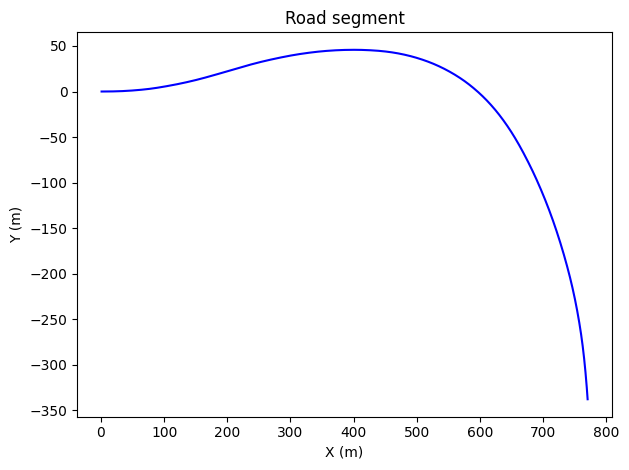

In [146]:
clipped_wn_curvature = np.clip(white_noise_curvature, -kappa_max, kappa_max)

window_size = int(len(clipped_wn_curvature) / 2) # 50% of the road length as smoothing
window = np.ones(window_size) / window_size
smooth_clipped_wn_curvature = np.convolve(clipped_wn_curvature, window, mode='same')

x, y = integrate_road(smooth_clipped_wn_curvature)
plot_road(x, y)

#### Adding random straight segments

It kind of looks like a road segment now, but maybe a bit *too* smooth. Real roads also have perfectly straight sections as that is simply cheaper and more efficient. Let's define two hyperparameters to add random straight sections:

- `straight_section_prob`: The probability that at step $i$, a straight section will start at step $i+1$.
- `straight_section_max_rel_size`: The maximum size the straight section is allowed to be, relative to total number of points.

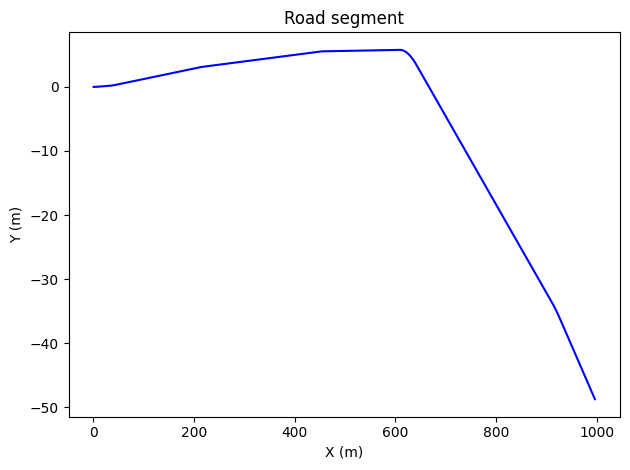

In [ ]:
curvature = smooth_clipped_wn_curvature.copy()
num_points = len(curvature)

straight_section_prob = 0.1
straight_section_max_rel_size = 0.3

i = 0
while i < num_points:
    if np.random.rand() < straight_section_prob:
        # Random straight segment length
        max_len = int(num_points * straight_section_max_rel_size)
        seg_len = np.random.randint(1, max_len + 1)
        curvature[i:i+seg_len] = 0  # set curvature to zero for straight
        i += seg_len  # skip over straight segment
    else:
        i += 1
        
x, y = integrate_road(curvature)
plot_road(x, y)

#### A few more examples

The road now has random straight sections that looks more like a road that might be built; somewhat realistic possible curves, restricted by a minimum turning radius, straight sections, but because it is based on random $\kappa_i$ there can be a large variability between road segments:

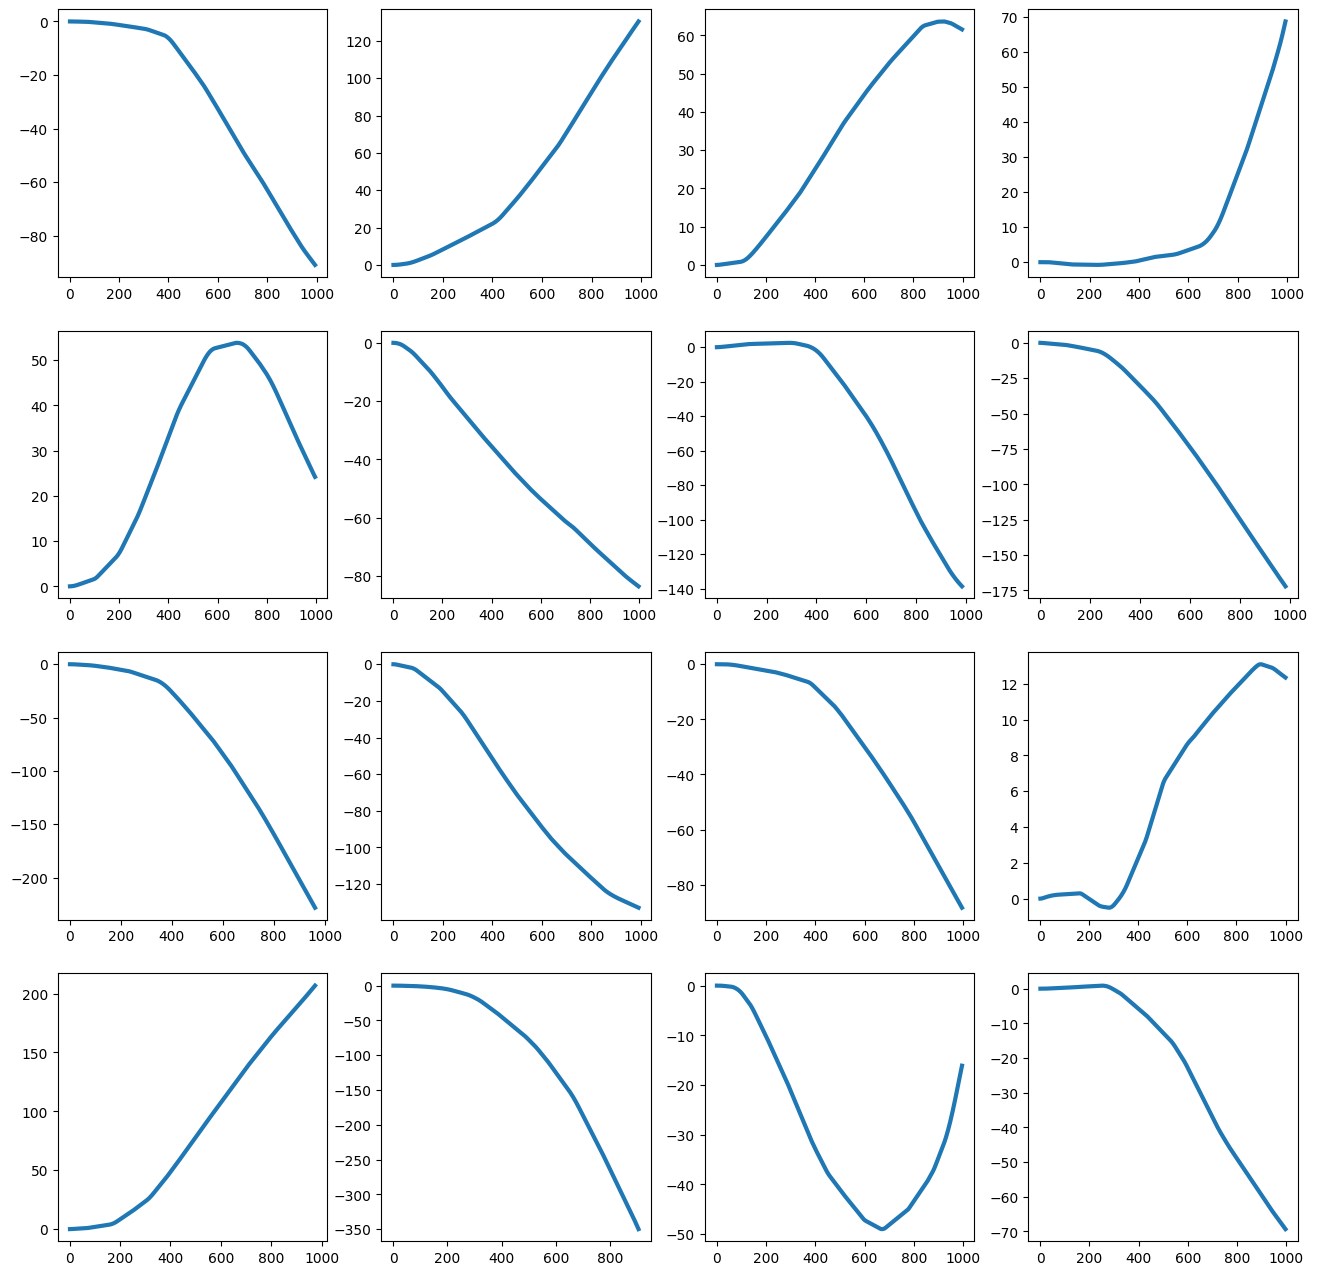

In [143]:
kappa_max = 1 / 25
num_points = 1000
straight_section_prob = 0.05
straight_section_max_rel_size = 0.1

# Create a 4x4 grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for ax in axes.flat:
    curvature = np.random.randn(num_points)
    clipped_curvature = np.clip(curvature, -kappa_max, kappa_max)
    window_size = int(len(clipped_curvature) / 2) # 50% of the road length as smoothing
    window = np.ones(window_size) / window_size
    smoothed_clipped_curvature = np.convolve(clipped_curvature, window, mode='same')

    i = 0
    while i < num_points:
        if np.random.rand() < straight_section_prob:
            max_len = int(num_points * straight_section_max_rel_size)
            seg_len = np.random.randint(1, max_len + 1)
            smoothed_clipped_curvature[i:i+seg_len] = 0
            i += seg_len
        else:
            i += 1
    x, y = integrate_road(smoothed_clipped_curvature)
    ax.plot(x, y, linewidth=3)

We now can randomly generate discrete planar curves that (kind of) look like real roads.